In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

plt.style.use("ggplot")
pd.set_option("display.max_columns",None)

In [3]:
diabetes = pd.read_csv("../data/processed/diabetes_processed.csv")

print(diabetes.shape)

display(diabetes.head())

(96146, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [4]:
X_diabetes = diabetes.drop("diabetes",axis=1)

y_diabetes = diabetes["diabetes"]

print(X_diabetes.shape)
print(y_diabetes.shape)

(96146, 8)
(96146,)


In [6]:
print(X_diabetes.dtypes)

gender                   int64
age                    float64
hypertension             int64
heart_disease            int64
smoking_history          int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
dtype: object


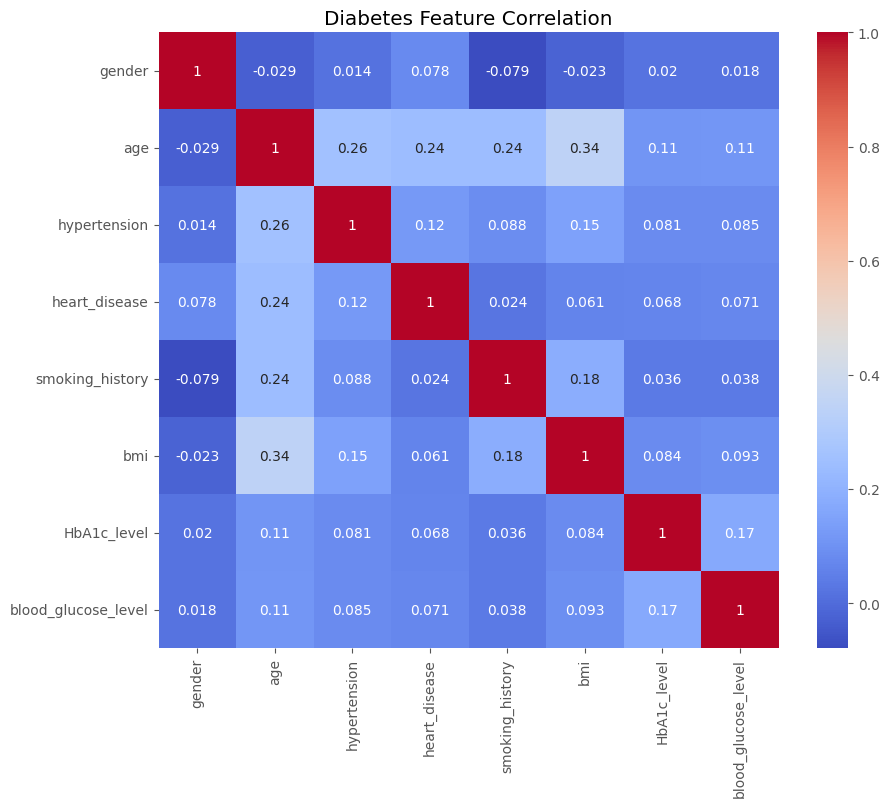

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(
    X_diabetes.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Diabetes Feature Correlation")

plt.show()

In [8]:
model = RandomForestClassifier(random_state=42)

model.fit(X_diabetes,y_diabetes)

importance = pd.DataFrame({
    "Feature":X_diabetes.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Feature,Importance
6,HbA1c_level,0.395887
7,blood_glucose_level,0.318824
5,bmi,0.123821
1,age,0.102636
4,smoking_history,0.027672
2,hypertension,0.015569
3,heart_disease,0.009344
0,gender,0.006247


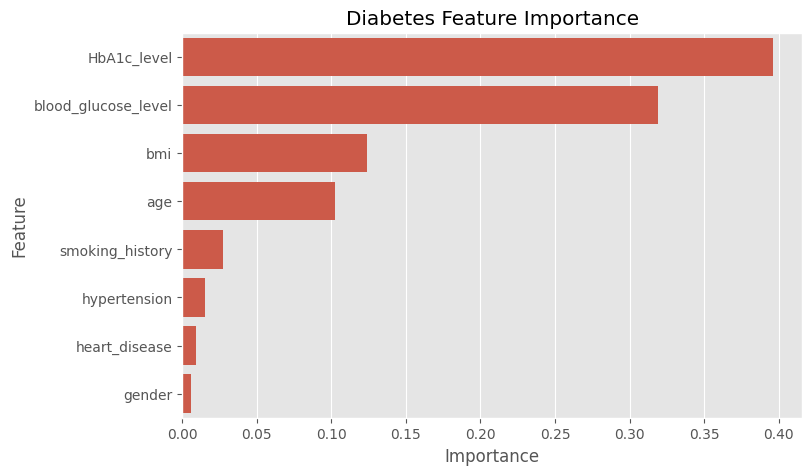

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Diabetes Feature Importance")

plt.show()

Heart

In [10]:
heart = pd.read_csv("../data/processed/heart_processed.csv")

print(heart.shape)

display(heart.head())

(66792, 12)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [11]:
X_heart = heart.drop("cardio",axis=1)

y_heart = heart["cardio"]

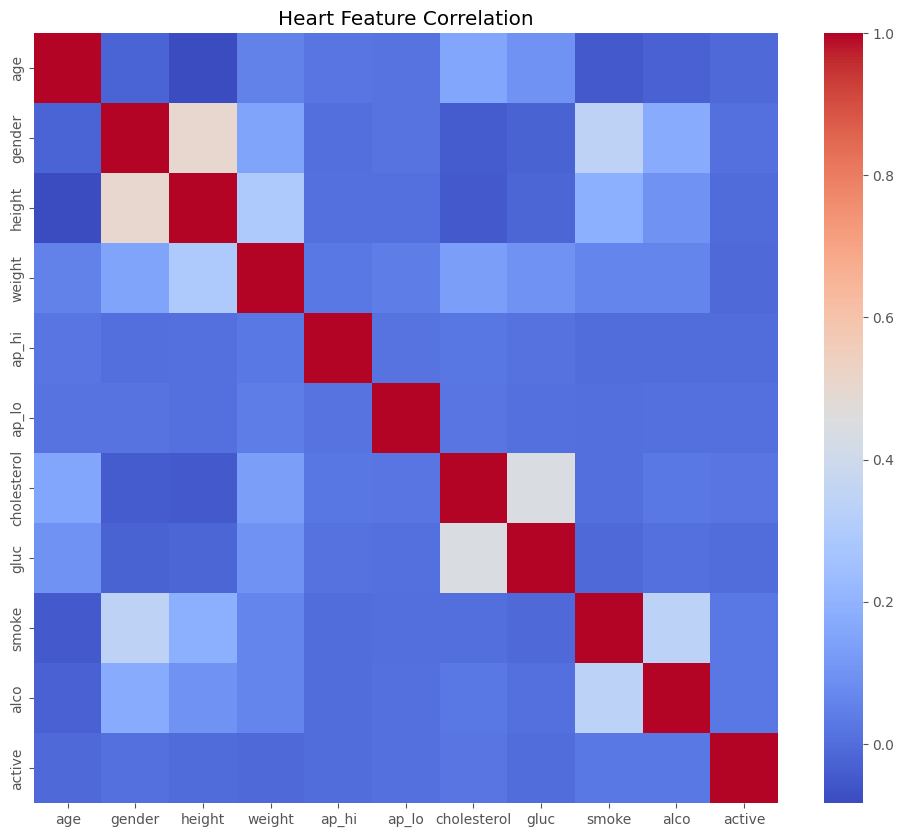

In [13]:
plt.figure(figsize=(12,10))

sns.heatmap(
    X_heart.corr(),
    cmap="coolwarm"
)

plt.title("Heart Feature Correlation")

plt.show()

In [14]:
model = RandomForestClassifier(random_state=42)

model.fit(X_heart,y_heart)

importance = pd.DataFrame({
    "Feature":X_heart.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Feature,Importance
3,weight,0.232962
2,height,0.215604
4,ap_hi,0.185856
0,age,0.164199
5,ap_lo,0.092918
6,cholesterol,0.039080
7,gluc,0.018741
1,gender,0.018230
10,active,0.015085
8,smoke,0.009126


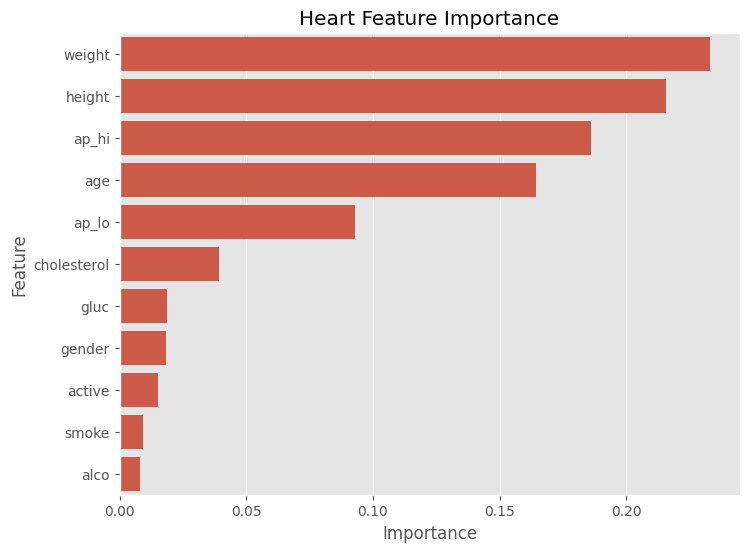

In [15]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Heart Feature Importance")

plt.show()

kidney

In [16]:
kidney = pd.read_csv("../data/processed/kidney_processed.csv")

print(kidney.shape)

display(kidney.head())

(1659, 52)


,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes,PreviousAcuteKidneyInjury,UrinaryTractInfections,SystolicBP,DiastolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,ProteinInUrine,ACR,SerumElectrolytesSodium,SerumElectrolytesPotassium,SerumElectrolytesCalcium,SerumElectrolytesPhosphorus,HemoglobinLevels,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,ACEInhibitors,Diuretics,NSAIDsUse,Statins,AntidiabeticMedications,Edema,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
0,71,0,0,0,2,31.069414,1,5.128112,1.676220,0.240386,4.076434,0,0,0,0,0,113,83,72.510788,9.212397,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,207.728670,85.863656,21.967957,212.095215,0,0,4.563139,1,0,0,3.563894,6.992244,4.518513,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1
1,34,0,0,1,3,29.692119,1,18.609552,8.377574,6.503233,7.652813,1,1,0,0,0,120,67,100.848875,4.604989,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,189.450727,86.378670,87.569756,255.451314,0,0,9.097002,0,0,0,5.327336,0.356290,2.202222,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1
2,80,1,1,0,1,37.394822,1,11.882429,9.607401,2.104828,4.392786,0,0,0,0,0,147,106,160.989441,5.432599,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,284.137622,132.269872,20.049798,251.902583,0,1,3.851249,1,0,0,4.855420,4.674069,5.967271,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1
3,40,0,2,0,1,31.329680,0,16.020165,0.408871,6.964422,6.282274,0,0,0,0,0,117,65,188.506620,4.144466,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,235.112124,93.443669,58.260291,392.338425,0,0,7.881765,0,0,0,8.531685,5.691455,2.176387,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1
4,43,0,1,1,2,23.726311,0,7.944146,0.780319,3.097796,4.021639,0,0,0,0,0,98,66,82.156699,4.262979,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,258.277566,171.758356,21.583213,370.523877,1,1,4.179459,1,0,0,1.422320,2.273459,6.800993,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1


In [17]:
X_kidney = kidney.drop("Diagnosis",axis=1)

y_kidney = kidney["Diagnosis"]

In [18]:
print(X_kidney.dtypes)

Age                                int64
Gender                             int64
Ethnicity                          int64
SocioeconomicStatus                int64
EducationLevel                     int64
BMI                              float64
Smoking                            int64
AlcoholConsumption               float64
PhysicalActivity                 float64
DietQuality                      float64
SleepQuality                     float64
FamilyHistoryKidneyDisease         int64
FamilyHistoryHypertension          int64
FamilyHistoryDiabetes              int64
PreviousAcuteKidneyInjury          int64
UrinaryTractInfections             int64
SystolicBP                         int64
DiastolicBP                        int64
FastingBloodSugar                float64
HbA1c                            float64
SerumCreatinine                  float64
BUNLevels                        float64
GFR                              float64
ProteinInUrine                   float64
ACR             

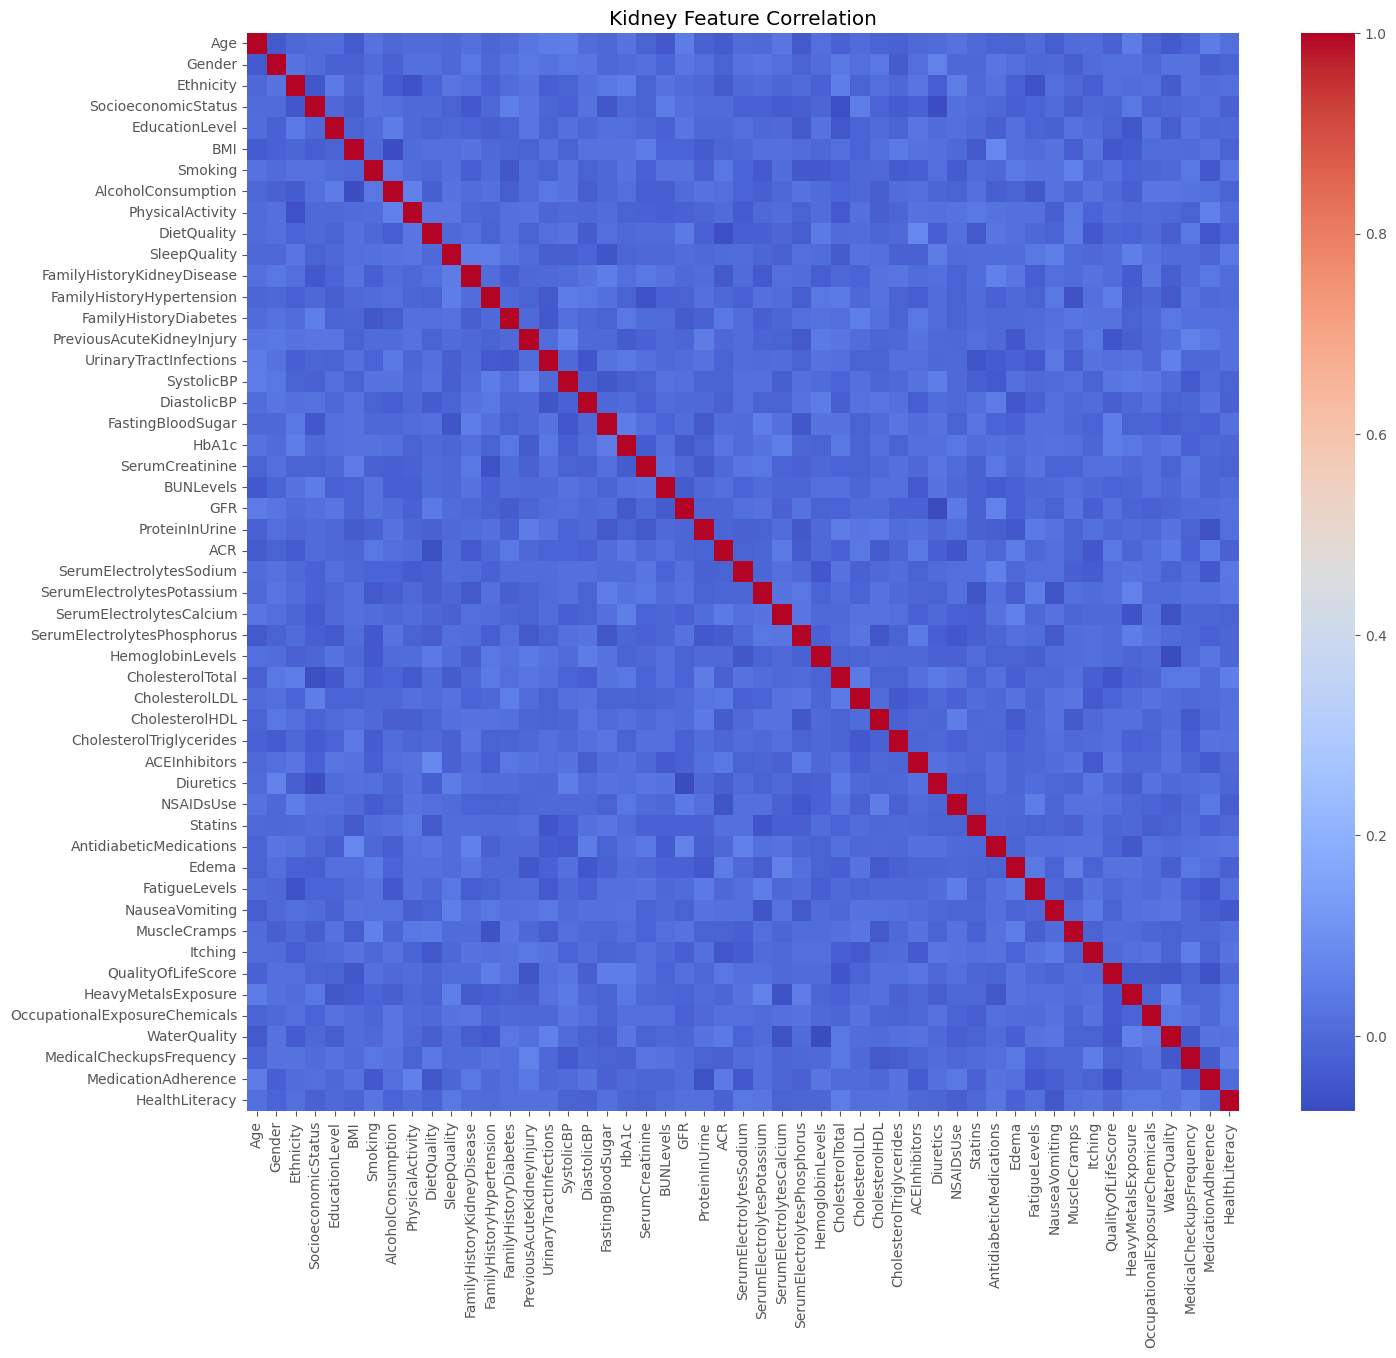

In [19]:
plt.figure(figsize=(16,14))

sns.heatmap(
    X_kidney.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Kidney Feature Correlation")

plt.show()

In [20]:
model = RandomForestClassifier(random_state=42)

model.fit(X_kidney,y_kidney)

importance = pd.DataFrame({
    "Feature":X_kidney.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

,Feature,Importance
20,SerumCreatinine,0.089314
22,GFR,0.064059
23,ProteinInUrine,0.058699
43,Itching,0.038809
21,BUNLevels,0.036526
42,MuscleCramps,0.035569
18,FastingBloodSugar,0.035453
25,SerumElectrolytesSodium,0.033729
16,SystolicBP,0.028062
50,HealthLiteracy,0.026646


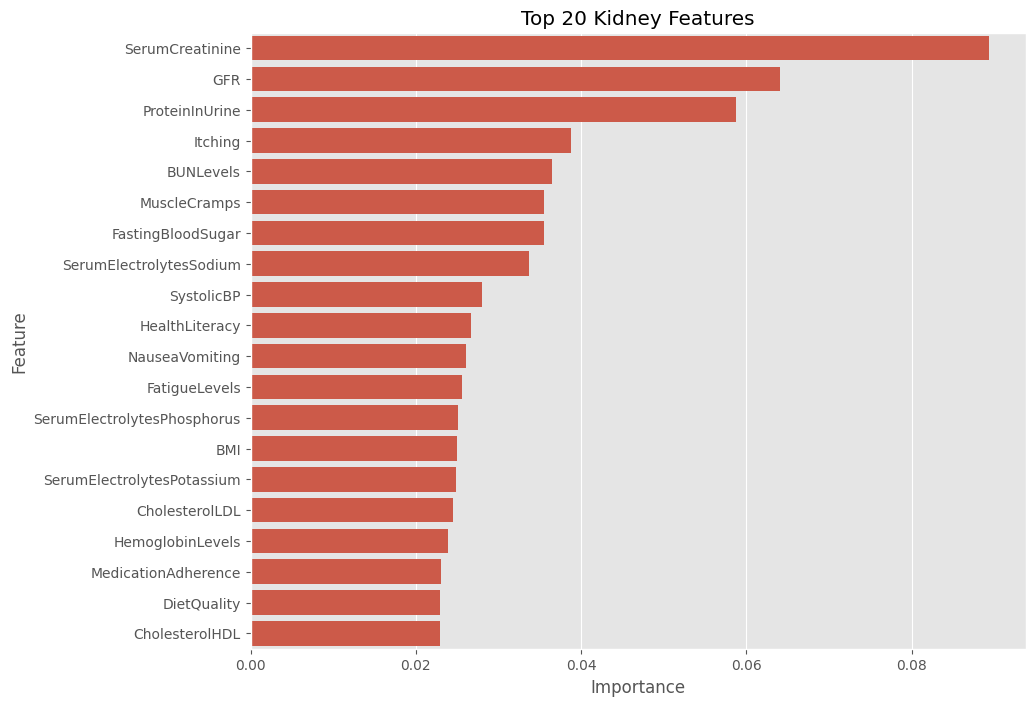

In [21]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Kidney Features")

plt.show()

In [23]:
diabetes.to_csv("../data/final/diabetes_final.csv",index=False)

heart.to_csv("../data/final/heart_final.csv",index=False)

kidney.to_csv("../data/final/kidney_final.csv",index=False)

print("Final datasets saved successfully.")

Final datasets saved successfully.
